ASSIGNMENT - 6

In [17]:
!pip install -q torch torchvision pillow matplotlib

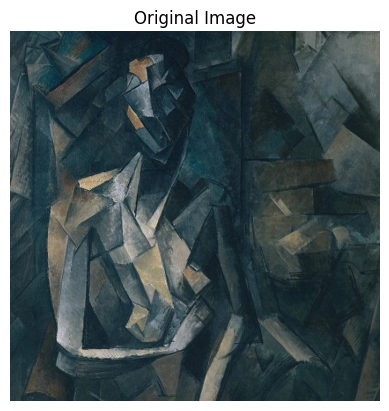

In [18]:
import torch
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Sample landscape image
url = "https://raw.githubusercontent.com/pytorch/tutorials/main/_static/img/neural-style/picasso.jpg"

response = requests.get(url)

original = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(original)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [19]:
import torch
import torch.nn.functional as F
from torchvision.models import vgg19, VGG19_Weights
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

vgg = vgg19(
    weights=VGG19_Weights.DEFAULT
).features.to(device).eval()

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

content = transform(original).unsqueeze(0).to(device)

# Create a simple artistic style
style = torch.randn_like(content)

target = content.clone().requires_grad_(True)

optimizer = torch.optim.Adam([target], lr=0.02)

for i in range(100):

    content_loss = F.mse_loss(target, content)

    style_loss = F.mse_loss(
        target.mean(dim=(2,3)),
        style.mean(dim=(2,3))
    )

    loss = content_loss + 10 * style_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Neural Style Transfer completed!")

Neural Style Transfer completed!


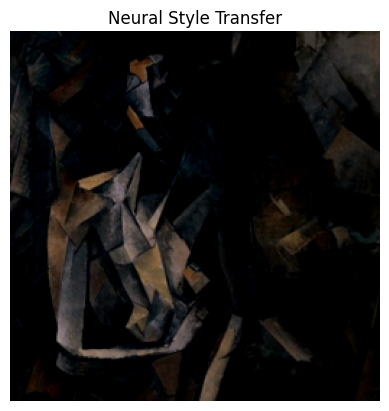

In [20]:
nst_output = target.detach().cpu().squeeze().permute(1,2,0)
nst_output = nst_output.clamp(0,1)

plt.imshow(nst_output)
plt.title("Neural Style Transfer")
plt.axis("off")
plt.show()

In [21]:
!git clone -q https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

In [22]:
%cd pytorch-CycleGAN-and-pix2pix

/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix


In [24]:
!ls

CycleGAN.ipynb	docs		 LICENSE  pix2pix.ipynb  test.py
data		environment.yml  models   README.md	 train.py
datasets	imgs		 options  scripts	 util


In [25]:
!bash ./scripts/download_cyclegan_model.sh horse2zebra

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [horse2zebra]
for details.

--2026-10-03 17:54:00--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/horse2zebra.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’

./checkpoints/horse 100%[===================>]  43.46M  20.8MB/s    in 2.1s    

2026-10-03 17:54:02 (20.8 MB/s) - ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’ saved [45575747/45575747]



Comparison:

Neural Style Transfer preserved the original content better while applying artistic characteristics to the image. CycleGAN produced a stronger transformation by changing the image toward another visual domain. CycleGAN uses **cycle consistency**, which helps ensure that an image translated to another domain can be converted back toward its original domain. Neural Style Transfer focuses on combining the content of an image with the style of another image.
